In [80]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [82]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [83]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [84]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [85]:
from data.devkit_semantics.devkit.helpers.labels import labels

mapping = np.full(256, 255, dtype=np.int32)
for label in labels:
    if label.id >= 0:
        mapping[label.id] = label.trainId
mapping[mapping == 255] = 19

In [86]:
def load_preprocess(image_path, mask_path):
    raw_image = tf.io.read_file(image_path)
    raw_mask = tf.io.read_file(mask_path)

    decoded_image = tf.image.decode_png(raw_image, channels=3)
    decoded_mask = tf.image.decode_png(raw_mask, channels=1)

    resized_image = tf.image.resize(decoded_image, [128,384])
    resized_mask = tf.image.resize(decoded_mask, [128,384], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    label_mapping = tf.constant(mapping, dtype=tf.int32)
    resized_mask = tf.gather(label_mapping, tf.cast(resized_mask, tf.int32))

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [87]:
dataset = dataset.map(load_preprocess)

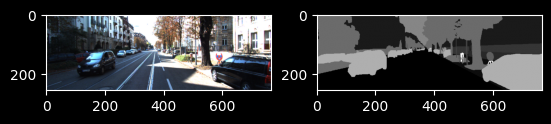

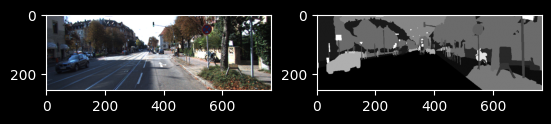

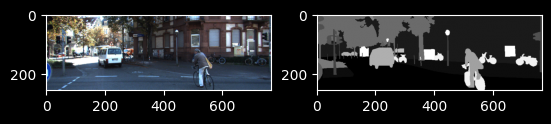

In [88]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [89]:
batch_size = 8
train_ds = dataset.take(160).shuffle(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [90]:
import importlib
import unet
importlib.reload(unet)
from unet import build_unet

In [91]:
model = build_unet((128,384, 3), 20)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 768,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 256, 768,  │      1,792 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 256, 768,  │     36,928 │ conv2d_95[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 128, 384,  │          0 │ conv2d_96[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 128, 384,  │     73,856 │ max_pooling2d_20… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 128, 384,  │    147,584 │ conv2d_97[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 64, 192,   │          0 │ conv2d_98[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 64, 192,   │    295,168 │ max_pooling2d_21… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 64, 192,   │    590,080 │ conv2d_99[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 32, 96,    │          0 │ conv2d_100[0][0]  │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 32, 96,    │  1,180,160 │ max_pooling2d_22… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 32, 96,    │  2,359,808 │ conv2d_101[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 16, 48,    │          0 │ conv2d_102[0][0]  │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 16, 48,    │  4,719,616 │ max_pooling2d_23… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 16, 48,    │  9,438,208 │ conv2d_103[0][0]  │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_20 │ (None, 32, 96,    │  2,097,664 │ conv2d_104[0][0]  │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_20      │ (None, 32, 96,    │          0 │ conv2d_transpose

 Total params: 31,032,980 (118.38 MB)

 Trainable params: 31,032,980 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [92]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=20, sparse_y_pred=False, ignore_class=19)
    ]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir='logs/batchnorm_lr0.001')]
)

model.save('checkpoints/batchnorm_20epochs.keras')

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 98s 5s/step - accuracy: 0.3281 - loss: 2.2637 - mean_io_u_11: 0.0379 - val_accuracy: 0.4566 - val_loss: 1.9203 - val_mean_io_u_11: 0.0615
Epoch 2/20
 5/20 ━━━━━━━━━━━━━━━━━━━━ 1:52 7s/step - accuracy: 0.5191 - loss: 1.6919 - mean_io_u_11: 0.0792

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step


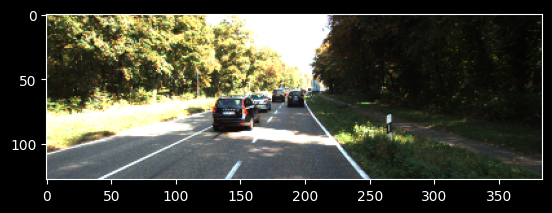

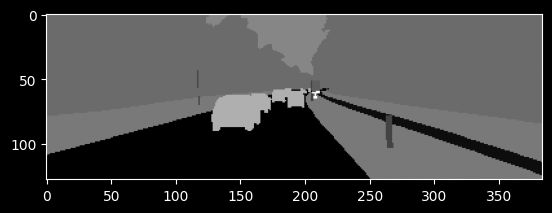

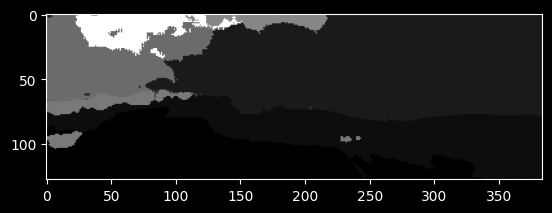

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


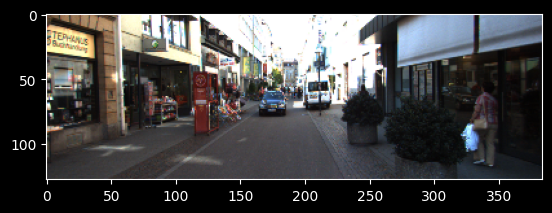

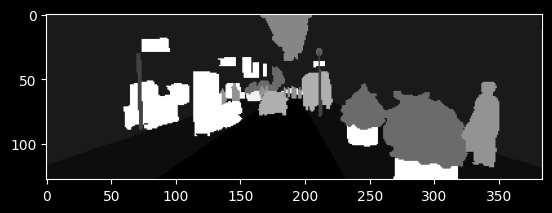

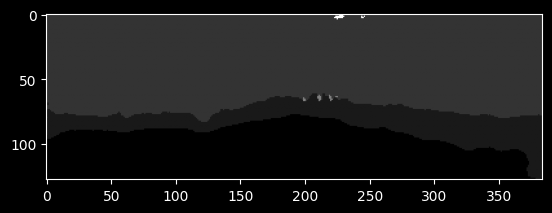

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


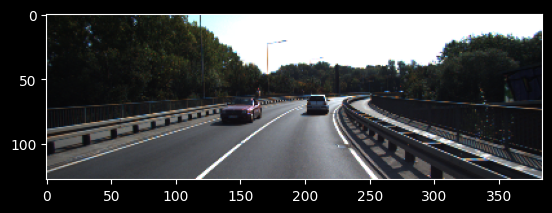

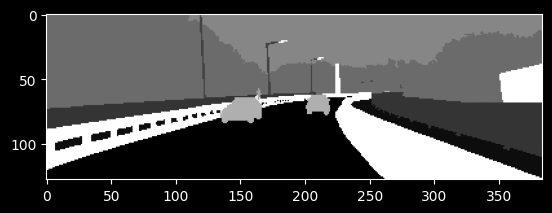

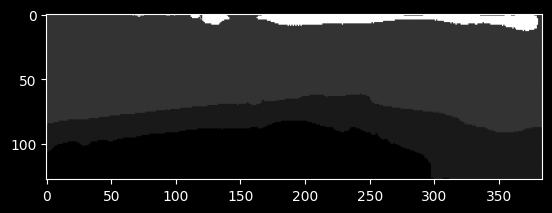

In [79]:
for image, mask in val_ds.take(3):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)

    plt.imshow(image[0])
    plt.show()
    plt.imshow(tf.squeeze(mask[0]), cmap='gray')
    plt.show()
    plt.imshow(predicted_mask[0], cmap='gray')
    plt.show()